In [7]:
import torch
import torch.nn as nn
import numpy as np
from model import LSTMClassifier

In [8]:
def predict(model, df, feature_cols, window=60, device="cpu"):
    """
    df: DataFrame с уже посчитанными фичами (те же, что при обучении!)
    Возвращает предсказание для ПОСЛЕДНЕГО окна в df
    """
    model.eval()
    model.to(device)
    
    features = df[feature_cols].values.astype(np.float32)
    
    if len(features) < window:
        raise ValueError(f"Недостаточно данных: нужно минимум {window} свечей, получено {len(features)}")
    
    x = features[-window:]  # last window
    
    if np.isnan(x).any() or np.isinf(x).any():
        raise ValueError(f"NaN/Inf в входных данных! NaN count: {np.isnan(x).sum()}, Inf count: {np.isinf(x).sum()}")
    
    x_tensor = torch.tensor(x).unsqueeze(0).to(device)  # batch dimension -> (1, window, n_features)
    
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()
    
    class_names = {0: "down", 1: "flat", 2: "up"}
    return {
        "prediction": class_names[pred_class],
        "probabilities": {
            "down": probs[0][0].item(),
            "flat": probs[0][1].item(),
            "up": probs[0][2].item()
        }
    }

In [ ]:
import pandas as pd
from model import prepare_features_and_labels, feature_cols

# нужно заново создать модель с ТЕМИ ЖЕ параметрами архитектуры
model = LSTMClassifier(n_features=5, hidden_size=64, num_layers=2, num_classes=3)
model.load_state_dict(torch.load("models/lstm_1440_0046_23.pt", map_location="cpu"))
model.eval()  # важно! переключает dropout/batchnorm в режим инференса

LSTMClassifier(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [ ]:
import random
intervals = []

for i in range(100):
    random_hour = random.randint(0,10000)
    start = ( 1784365200-60*60*random_hour-60*90 )*1000
    end = ( 1784365200-60*60*random_hour )*1000
    intervals.append([start, end])
 
print(intervals)  
intervals = [[1767443400000, 1767448800000], [1766665800000, 1766671200000], [1764365400000, 1764370800000], [1748554200000, 1748559600000], [1777069800000, 1777075200000], [1764484200000, 1764489600000], [1765765800000, 1765771200000], [1770834600000, 1770840000000], [1763649000000, 1763654400000], [1749357000000, 1749362400000], [1754073000000, 1754078400000], [1780180200000, 1780185600000], [1773451800000, 1773457200000], [1754526600000, 1754532000000], [1781191800000, 1781197200000], [1754530200000, 1754535600000], [1758047400000, 1758052800000], [1773358200000, 1773363600000], [1780158600000, 1780164000000], [1773876600000, 1773882000000], [1769092200000, 1769097600000], [1775169000000, 1775174400000], [1783985400000, 1783990800000], [1752571800000, 1752577200000], [1754879400000, 1754884800000], [1751002200000, 1751007600000], [1750419000000, 1750424400000], [1773088200000, 1773093600000], [1776983400000, 1776988800000], [1751916600000, 1751922000000], [1755999000000, 1756004400000], [1778034600000, 1778040000000], [1757320200000, 1757325600000], [1771597800000, 1771603200000], [1775615400000, 1775620800000], [1778704200000, 1778709600000], [1782102600000, 1782108000000], [1756153800000, 1756159200000], [1749594600000, 1749600000000], [1777998600000, 1778004000000], [1764732600000, 1764738000000], [1758015000000, 1758020400000], [1766133000000, 1766138400000], [1766356200000, 1766361600000], [1781476200000, 1781481600000], [1781595000000, 1781600400000], [1764084600000, 1764090000000], [1767331800000, 1767337200000], [1757802600000, 1757808000000], [1764444600000, 1764450000000], [1748388600000, 1748394000000], [1774125000000, 1774130400000], [1755934200000, 1755939600000], [1765103400000, 1765108800000], [1759368600000, 1759374000000], [1749231000000, 1749236400000], [1754159400000, 1754164800000], [1763670600000, 1763676000000], [1752341400000, 1752346800000], [1765499400000, 1765504800000], [1763386200000, 1763391600000], [1760178600000, 1760184000000], [1759091400000, 1759096800000], [1781580600000, 1781586000000], [1770298200000, 1770303600000], [1783783800000, 1783789200000], [1754731800000, 1754737200000], [1783636200000, 1783641600000], [1771270200000, 1771275600000], [1748964600000, 1748970000000], [1769157000000, 1769162400000], [1780612200000, 1780617600000], [1760941800000, 1760947200000], [1761982200000, 1761987600000], [1773012600000, 1773018000000], [1757953800000, 1757959200000], [1748773800000, 1748779200000], [1750278600000, 1750284000000], [1749540600000, 1749546000000], [1776493800000, 1776499200000], [1765909800000, 1765915200000], [1765935000000, 1765940400000], [1782307800000, 1782313200000], [1775475000000, 1775480400000], [1777757400000, 1777762800000], [1762943400000, 1762948800000], [1765513800000, 1765519200000], [1769542200000, 1769547600000], [1757143800000, 1757149200000], [1763224200000, 1763229600000], [1777350600000, 1777356000000], [1781573400000, 1781578800000], [1776263400000, 1776268800000], [1756884600000, 1756890000000], [1768523400000, 1768528800000], [1750055400000, 1750060800000], [1781512200000, 1781517600000], [1757849400000, 1757854800000], [1780817400000, 1780822800000], [1760275800000, 1760281200000]]

[[1767443400000, 1767448800000], [1766665800000, 1766671200000], [1764365400000, 1764370800000], [1748554200000, 1748559600000], [1777069800000, 1777075200000], [1764484200000, 1764489600000], [1765765800000, 1765771200000], [1770834600000, 1770840000000], [1763649000000, 1763654400000], [1749357000000, 1749362400000], [1754073000000, 1754078400000], [1780180200000, 1780185600000], [1773451800000, 1773457200000], [1754526600000, 1754532000000], [1781191800000, 1781197200000], [1754530200000, 1754535600000], [1758047400000, 1758052800000], [1773358200000, 1773363600000], [1780158600000, 1780164000000], [1773876600000, 1773882000000], [1769092200000, 1769097600000], [1775169000000, 1775174400000], [1783985400000, 1783990800000], [1752571800000, 1752577200000], [1754879400000, 1754884800000], [1751002200000, 1751007600000], [1750419000000, 1750424400000], [1773088200000, 1773093600000], [1776983400000, 1776988800000], [1751916600000, 1751922000000], [1755999000000, 1756004400000], [177803

win True, profit 105.5 points, ttl 105.5, winrate 1.0
win True, profit 11.4 points, ttl 116.9, winrate 1.0
win True, profit 194.7 points, ttl 311.6, winrate 1.0
win True, profit 54.4 points, ttl 366.0, winrate 1.0
win True, profit 246.3 points, ttl 612.3, winrate 1.0
win False, profit -18.0 points, ttl 594.3, winrate 0.833
win True, profit 37.7 points, ttl 632.0, winrate 0.857
win False, profit -54.5 points, ttl 577.5, winrate 0.75
win True, profit 23.9 points, ttl 601.4, winrate 0.778
win True, profit 11.1 points, ttl 612.5, winrate 0.8
win False, profit -224.0 points, ttl 388.5, winrate 0.727
win False, profit -203.5 points, ttl 185.0, winrate 0.667
win True, profit 68.0 points, ttl 253.0, winrate 0.692
win True, profit 110.7 points, ttl 363.7, winrate 0.714
win True, profit 33.2 points, ttl 396.9, winrate 0.733
win False, profit -722.1 points, ttl -325.2, winrate 0.688
win False, profit -66.6 points, ttl -391.8, winrate 0.647
win False, profit -53.0 points, ttl -444.8, winrate 0.611

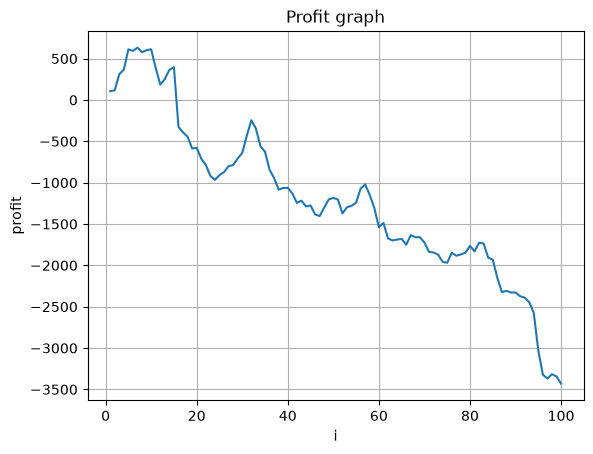

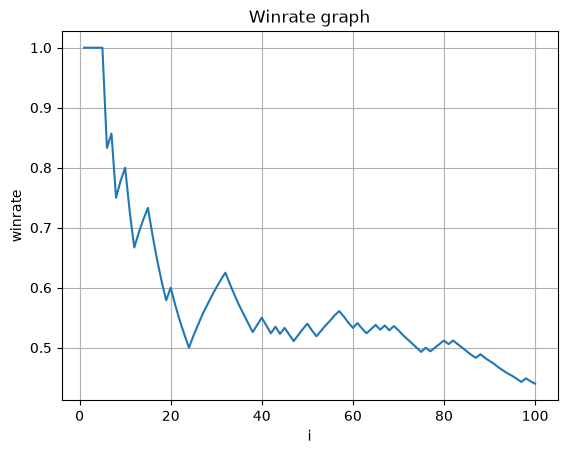

In [11]:
from dataWorker import *
from datetime import datetime
from dataWorker import getOHLC
import matplotlib.pyplot as plt
# loading real data for test

profit_ttl = 0
wins = 0
profit_history = []
winrate_history = []
iters = 100
for i, interval in enumerate(intervals[:iters]):
    start = interval[0]
    end = interval[1]
    test_df = getOHLC('BTCUSDT', start, end, normalize=True)
    test_df = prepare_features_and_labels(test_df, horizon=5, flat_threshold=0.001) 
    #print(f"Selected interval from {datetime.fromtimestamp(start//1000)} to {datetime.fromtimestamp(end//1000)}")
    result = predict(model, test_df, feature_cols, window=5)
    #print(result)
    
    # collecting data from exchange
    df_plot = getOHLC('BTCUSDT', start, end)
    df_plot = df_plot.set_index("timestamp")
    df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
    df_final = df_final.set_index("timestamp")

    # calculate price change
    open_price = float(df_final.iloc[0]['open'])
    close_price = float(df_final.iloc[4]['close'])
    price_change = round(close_price - open_price, 3)
    
    if result.get('prediction') == 'down':
        profit = price_change * -1
    if result.get('prediction') == 'up':
        profit = price_change
        
    if profit>0: wins += 1
    profit_ttl += profit
    profit_ttl = round(profit_ttl, 2)
    print(f"win {profit>0}, profit {profit} points, ttl {profit_ttl}, winrate {round(wins/(i+1),3)}")
    
    profit_history.append(profit_ttl)
    winrate_history.append(round(wins/(i+1),3))
    
    
print(f"Profit: {profit_ttl} points with winrate {round(wins/iters,2)}")    

fig, ax = plt.subplots()
t = np.arange(1,iters+1, 1)
ax.plot(t, profit_history)
ax.set(xlabel='i', ylabel='profit',
       title='Profit graph')
ax.grid()
plt.show()

fig, ax = plt.subplots()
ax.plot(t, winrate_history)
ax.set(xlabel='i', ylabel='winrate',
       title='Winrate graph')
ax.grid()
plt.show()

In [12]:
# from dataWorker import getOHLC
# import mplfinance as mpf

# df_plot = getOHLC('BTCUSDT', start, end)
# df_plot = df_plot.set_index("timestamp")
# df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
# df_final = df_final.set_index("timestamp")

# open_price = float(df_final.iloc[0]['open'])
# close_price = float(df_final.iloc[4]['close'])

# profit = round(close_price - open_price, 3)
# if result.get('prediction') == 'down':
#     if profit < 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')
# if result.get('prediction') == 'up':
#     if profit > 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')

# # plotting
# fig, ax = mpf.plot(df_plot, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Input Data')
# fig,ax = mpf.plot(df_final, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Prediction Window')